# Spectral Analysis Extension Demo for `hvsrpy`

This notebook is designed to **test, demonstrate, and document** the new spectral-analysis modules.

It follows the overall style of the public `hvsrpy` example notebooks:
- clear sectioned workflow
- explicit preprocessing and processing settings
- `matplotlib` styling through `hvsrpy.HVSRPY_MPL_STYLE`
- compute first, then summarize/plot

## What this notebook covers

1. Standard HVSR preprocessing and processing
2. Restricting spectral calculations to the **same accepted HVSR windows**
3. Fourier Amplitude Spectrum (**FAS**) computation
4. Power Spectral Density (**PSD**) computation
5. Use of the `SpectralResult` object
6. Built-in spectral plotting helpers:
   - `plot_spectrum_component`
   - `plot_spectrum_results`
   - `plot_spectrum_summary`
7. Horizontal combination modes:
   - `geometric_mean`
   - `single_azimuth`
8. Custom 2×2 subplot composition using the low-level component plotter

> This notebook assumes the fork includes:
> - `hvsrpy.spectral_amplitude`
> - `hvsrpy.spectral_plotting`
> - `hvsrpy._spectral`


In [32]:

import pathlib

import numpy as np
import matplotlib.pyplot as plt

import hvsrpy
from hvsrpy.spectral_amplitude import (
    SpectralResult,
    compute_fourier_amplitude_spectra,
    compute_power_spectral_density,
    smooth_spectra,
    plot_spectrum_component,
    plot_spectrum_results,
    plot_spectrum_summary,
)

plt.style.use(hvsrpy.HVSRPY_MPL_STYLE)


## Input Data

The official `hvsrpy` example notebooks use MiniSEED example files in the `examples/data` folder.  
This notebook uses the same kind of setup so you can drop it into your fork and run it from the examples directory.

Change the file name below if you want to test another record.


In [33]:

# Input file name (may be a relative or full path).
fnames = [["./data/UT.STN11.A2_C50.miniseed"]]
# fnames = [["./data/UT.STN11.A2_C150.miniseed"]]
# fnames = [["./data/UT.STN11.A2_C300.miniseed"]]

print(f"Number of recordings: {len(fnames)}")
for fname_set in fnames:
    for file in fname_set:
        if not pathlib.Path(file).exists():
            raise FileNotFoundError(
                f"file {file} not found; run this notebook from the examples directory "
                "or update `fnames` to point to a valid record."
            )
print("All files exist.")


Number of recordings: 1
All files exist.


## Preprocessing Settings


In [34]:

preprocessing_settings = hvsrpy.settings.HvsrPreProcessingSettings()
preprocessing_settings.detrend = "linear"
preprocessing_settings.window_length_in_seconds = 100
preprocessing_settings.orient_to_degrees_from_north = 0.0
preprocessing_settings.filter_corner_frequencies_in_hz = (None, None)
preprocessing_settings.ignore_dissimilar_time_step_warning = False

print("Preprocessing Summary")
print("-" * 60)
preprocessing_settings.psummary()


Preprocessing Summary
------------------------------------------------------------
hvsrpy_version                           : 2.1.0
orient_to_degrees_from_north             : 0.0
filter_corner_frequencies_in_hz          : (None, None)
window_length_in_seconds                 : 100
detrend                                  : linear
preprocessing_method                     : hvsr


## Processing Settings

This notebook demonstrates both:
- the usual `geometric_mean` horizontal combination, and
- `single_azimuth` horizontal rotation.

The default processing block below starts with `geometric_mean`.


In [35]:

processing_settings = hvsrpy.settings.HvsrTraditionalProcessingSettings()
processing_settings.window_type_and_width = ("tukey", 0.2)
processing_settings.smoothing = dict(
    operator="konno_and_ohmachi",
    bandwidth=40,
    center_frequencies_in_hz=np.geomspace(0.2, 50, 200),
)
processing_settings.method_to_combine_horizontals = "geometric_mean"
processing_settings.handle_dissimilar_time_steps_by = "frequency_domain_resampling"

print("Processing Summary")
print("-" * 60)
processing_settings.psummary()


Processing Summary
------------------------------------------------------------
hvsrpy_version                           : 2.1.0
window_type_and_width                    : ('tukey', 0.2)
smoothing                                :
     operator                            : konno_and_ohmachi
     bandwidth                           : 40
     center_frequencies_in_hz            : [0.2, 0.205626908165 ... 1767550226364, 50.0]
fft_settings                             : None
handle_dissimilar_time_steps_by          : frequency_domain_resampling
processing_method                        : traditional
method_to_combine_horizontals            : geometric_mean


## Read, Preprocess, and Process HVSR


In [36]:

srecords = hvsrpy.read(fnames)
srecords_preprocessed = hvsrpy.preprocess(srecords, preprocessing_settings)
hvsr = hvsrpy.process(srecords_preprocessed, processing_settings)


## Optional Frequency-Domain Rejection

The new spectral helpers are designed to work on the **same accepted windows** used for HVSR.

If you want to test the accepted-window workflow more explicitly, uncomment the rejection step below.


In [37]:

# Optional: apply a simple frequency-domain rejection step
_ = hvsrpy.frequency_domain_window_rejection(hvsr, n=2)

accepted_mask = np.asarray(hvsr.valid_window_boolean_mask, dtype=bool)
srecords_accepted = [rec for rec, keep in zip(srecords_preprocessed, accepted_mask) if keep]

print(f"Accepted windows for spectra: {len(srecords_accepted)} / {len(srecords_preprocessed)}")
if len(srecords_accepted) == 0:
    raise ValueError("No accepted windows available for spectral plotting.")


Accepted windows for spectra: 16 / 18


## Summarize HVSR Results



Statistical Summary:
--------------------


,Exponentitated Lognormal Median (units),Lognormal Standard Deviation (log units),-1 Lognormal Standard Deviation (units),+1 Lognormal Standard Deviation (units)
"Resonant Site Frequency, fn (Hz)",0.736,0.110,0.659,0.821
"Resonant Site Period, Tn (s)",1.359,0.110,1.518,1.218
"Resonance Amplitude, An",4.318,0.140,3.753,4.969


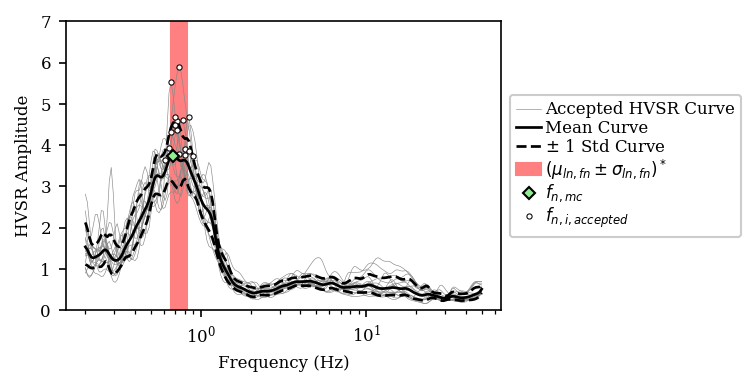

In [38]:

print("\nStatistical Summary:")
print("-" * 20)
hvsrpy.summarize_hvsr_statistics(hvsr)

(fig_hvsr, ax_hvsr) = hvsrpy.plot_single_panel_hvsr_curves(hvsr)
leg = ax_hvsr.get_legend()
if leg is not None:
    leg.remove()
ax_hvsr.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()


## Compute Spectra (FAS and PSD)

The compute functions now return a `SpectralResult` object instead of a plain dictionary.


In [39]:

fas_raw = compute_fourier_amplitude_spectra(
    srecords_accepted,
    processing_settings,
    include_horizontal=True,
    smooth=False,
)
fas_smooth = compute_fourier_amplitude_spectra(
    srecords_accepted,
    processing_settings,
    include_horizontal=True,
    smooth=True,
)

psd_raw = compute_power_spectral_density(
    srecords_accepted,
    processing_settings,
    include_horizontal=True,
    smooth=False,
)
psd_smooth = compute_power_spectral_density(
    srecords_accepted,
    processing_settings,
    include_horizontal=True,
    smooth=True,
)

print(type(fas_raw))
print(type(psd_raw))


<class 'hvsrpy._spectral.SpectralResult'>
<class 'hvsrpy._spectral.SpectralResult'>


## Inspect the `SpectralResult` Object

This cell highlights the main API:

- attribute access: `frequency`, `ns`, `ew`, `vt`, `horizontal`
- metadata: `spectrum_type`, `is_smoothed`
- convenience properties: `n_records`, `n_frequencies`
- compatibility helpers: `as_dict()`, `keys()`, `items()`


In [40]:

result = fas_smooth

print("Result type:", type(result).__name__)
print("Spectrum type:", result.spectrum_type)
print("Is smoothed:", result.is_smoothed)
print("Has horizontal:", result.has_horizontal)
print("n_records:", result.n_records)
print("n_frequencies:", result.n_frequencies)
print("frequency shape:", result.frequency.shape)
print("ns shape:", result.ns.shape)
print("Available keys:", result.keys())

# Backward-compatible dict-like access still works
print("horizontal" in result)
print(result["ns"].shape)


Result type: SpectralResult
Spectrum type: fas
Is smoothed: True
Has horizontal: True
n_records: 16
n_frequencies: 200
frequency shape: (200,)
ns shape: (16, 200)
Available keys: ('frequency', 'ns', 'ew', 'vt', 'horizontal', 'spectrum_type', 'is_smoothed')
True
(16, 200)


## Built-In Spectrum Summary Plots

These are the simplest package-level plotting entry points.


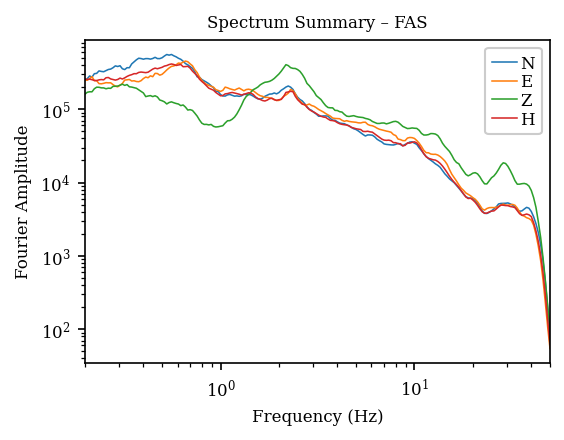

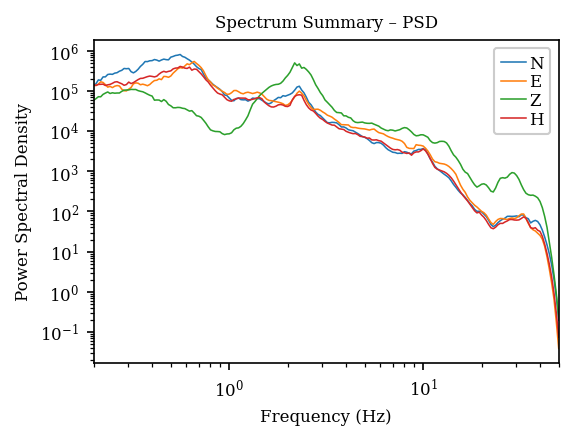

In [41]:

fig, ax = plot_spectrum_summary(
    fas_smooth,
    include_horizontal=True,
    statistic="median",
)
ax.set_title("Spectrum Summary – FAS")
plt.show()

fig, ax = plot_spectrum_summary(
    psd_smooth,
    include_horizontal=True,
    statistic="median",
)
ax.set_title("Spectrum Summary – PSD")
plt.show()


## Built-In Spectrum Results Plots

These show one subplot per component with:
- faint individual windows
- a summary overplot


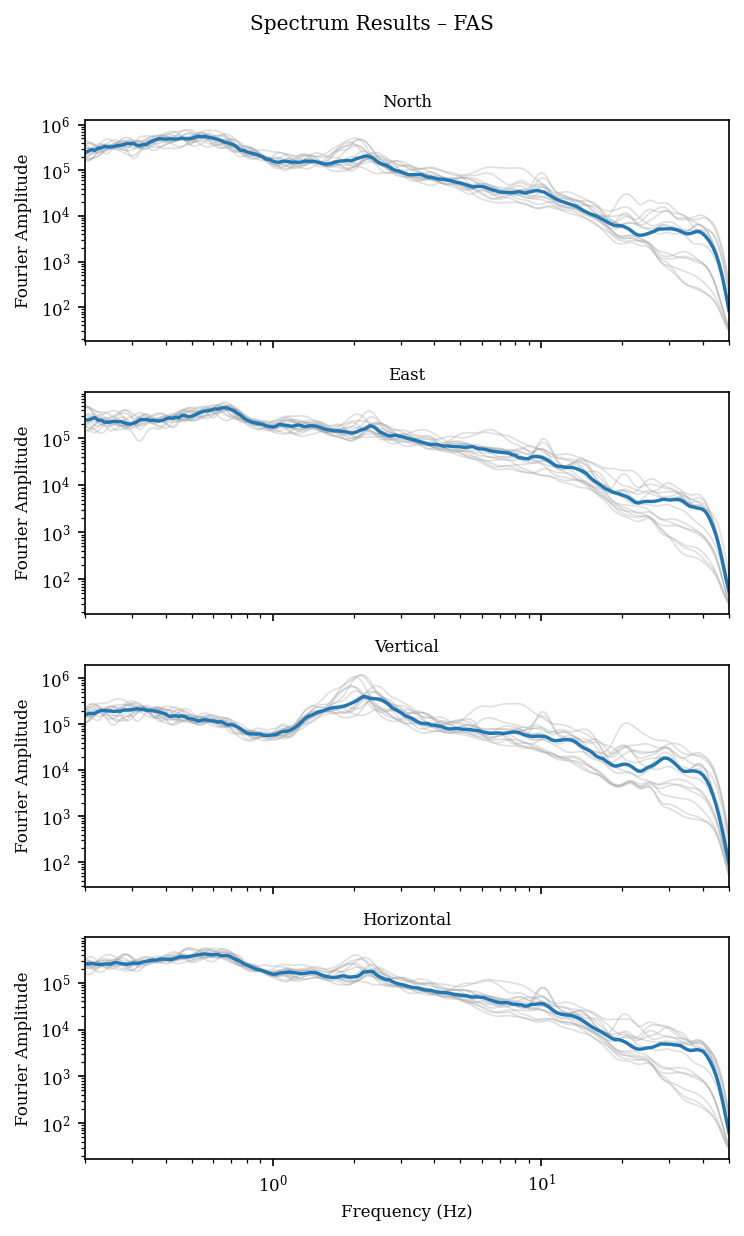

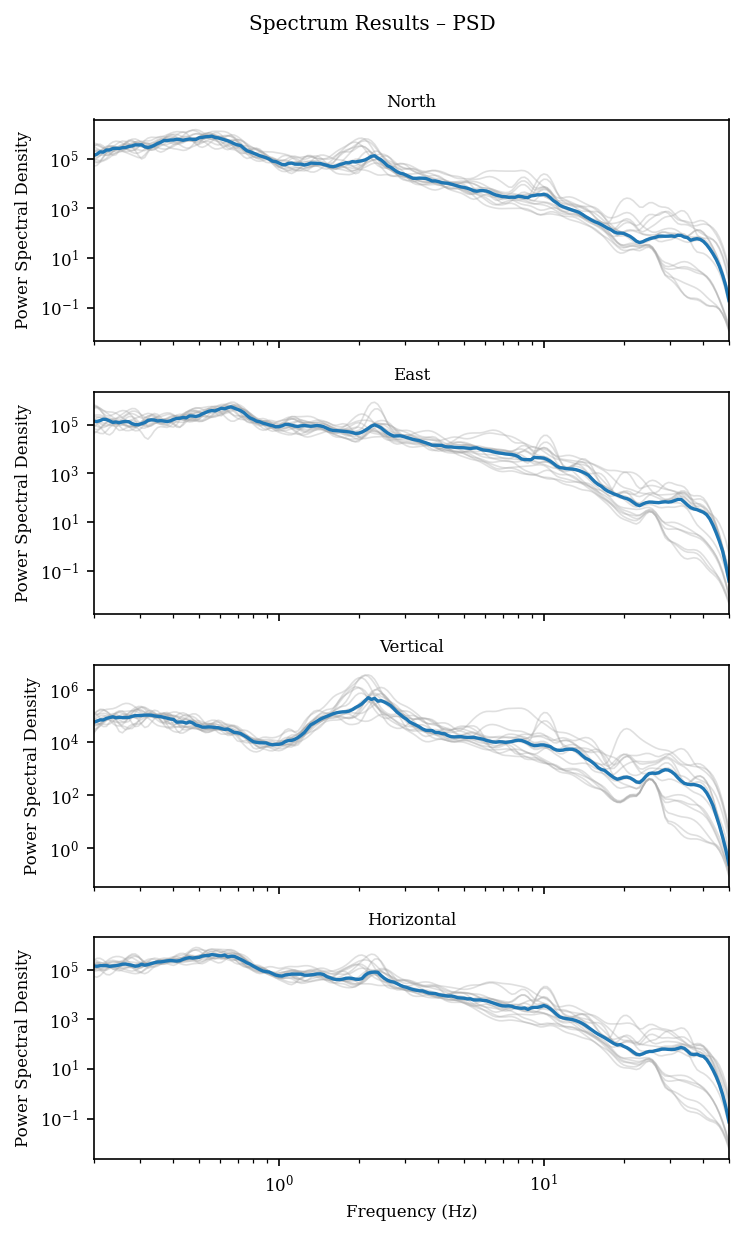

In [42]:

fig, axes = plot_spectrum_results(
    fas_smooth,
    include_horizontal=True,
    statistic="median",
)
fig.suptitle("Spectrum Results – FAS", y=1.02)
fig.tight_layout()
plt.show()

fig, axes = plot_spectrum_results(
    psd_smooth,
    include_horizontal=True,
    statistic="median",
)
fig.suptitle("Spectrum Results – PSD", y=1.02)
fig.tight_layout()
plt.show()


## Component-Level Plotting Primitive

The most flexible plotting helper is `plot_spectrum_component(...)`.

This makes it easy to build custom notebook layouts without changing the package code.


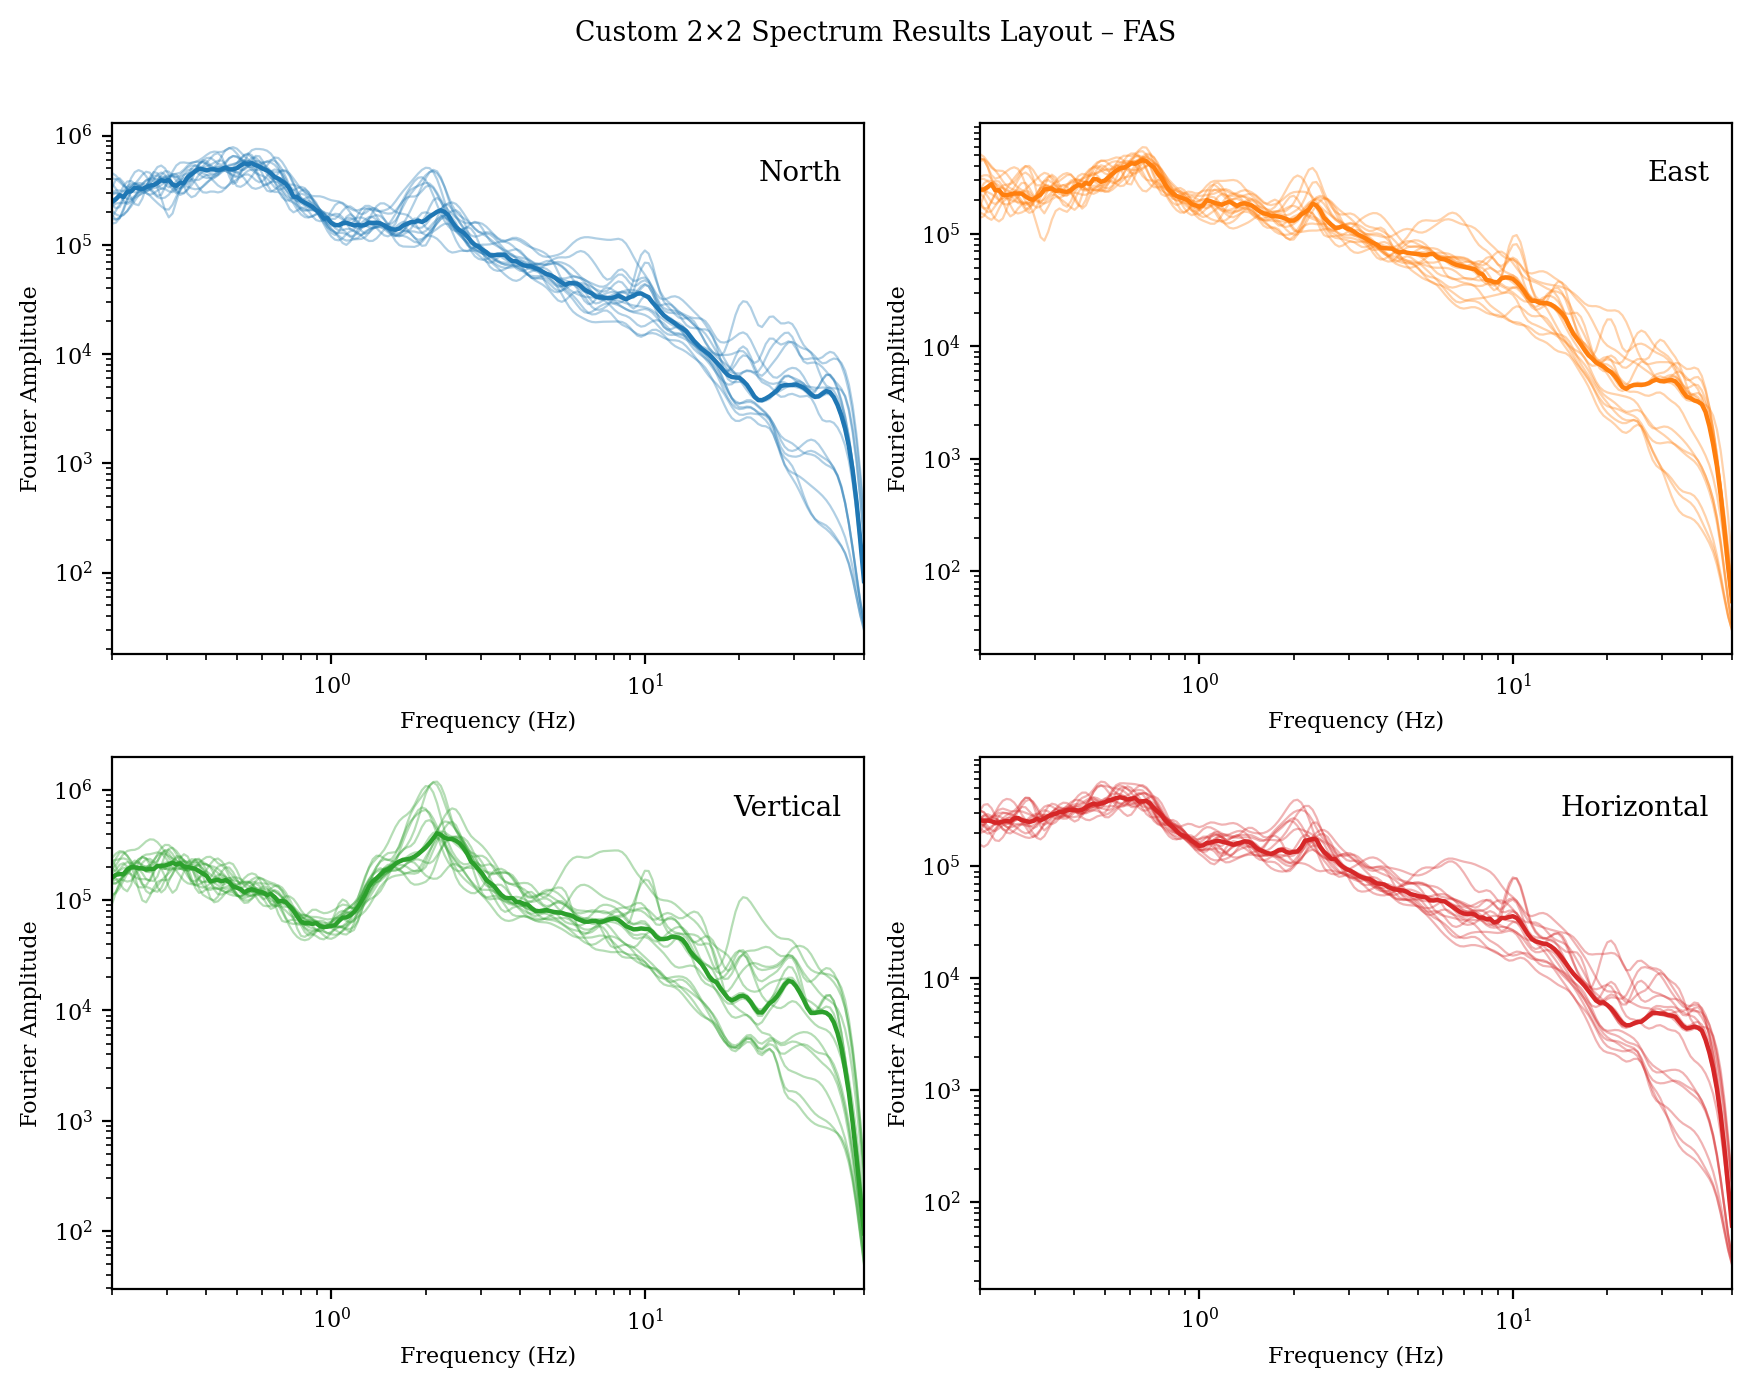

In [43]:

component_colors = {
    "ns": "C0",
    "ew": "C1",
    "vt": "C2",
    "horizontal": "C3",
}

xlim_use = (
    float(np.min(fas_smooth.frequency)),
    float(np.max(fas_smooth.frequency)),
)

fig, axs = plt.subplots(2, 2, figsize=(8.8, 7), dpi=200, sharex=True)

plot_spectrum_component(
    fas_smooth, "ns", ax=axs[0, 0],
    title=None, statistic="median",
    show_xlabel=True, show_ylabel=True,
    individual_color=component_colors["ns"],
    summary_color=component_colors["ns"],
)
plot_spectrum_component(
    fas_smooth, "ew", ax=axs[0, 1],
    title=None, statistic="median",
    show_xlabel=True, show_ylabel=True,
    individual_color=component_colors["ew"],
    summary_color=component_colors["ew"],
)
plot_spectrum_component(
    fas_smooth, "vt", ax=axs[1, 0],
    title=None, statistic="median",
    show_xlabel=True, show_ylabel=True,
    individual_color=component_colors["vt"],
    summary_color=component_colors["vt"],
)
if fas_smooth.has_horizontal:
    plot_spectrum_component(
        fas_smooth, "horizontal", ax=axs[1, 1],
        title=None, statistic="median",
        show_xlabel=True, show_ylabel=True,
        individual_color=component_colors["horizontal"],
        summary_color=component_colors["horizontal"],
    )
else:
    axs[1, 1].set_visible(False)

for ax in axs.flat:
    if ax.get_visible():
        ax.set_xlim(xlim_use)

for ax in axs[0, :]:
    ax.tick_params(labelbottom=True)

panel_labels = {
    (0, 0): "North",
    (0, 1): "East",
    (1, 0): "Vertical",
    (1, 1): "Horizontal",
}
for (i, j), label in panel_labels.items():
    ax = axs[i, j]
    if ax.get_visible():
        ax.text(
            0.97, 0.93, label,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2")
        )

fig.suptitle("Custom 2×2 Spectrum Results Layout – FAS", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


## Compare Unsmoothed and Smoothed Results

This helps verify:
- raw FFT / PSD output
- Konno–Ohmachi smoothing
- the change in frequency vector after smoothing


FAS raw frequencies: (16385,)
FAS smooth frequencies: (200,)
PSD raw frequencies: (16385,)
PSD smooth frequencies: (200,)


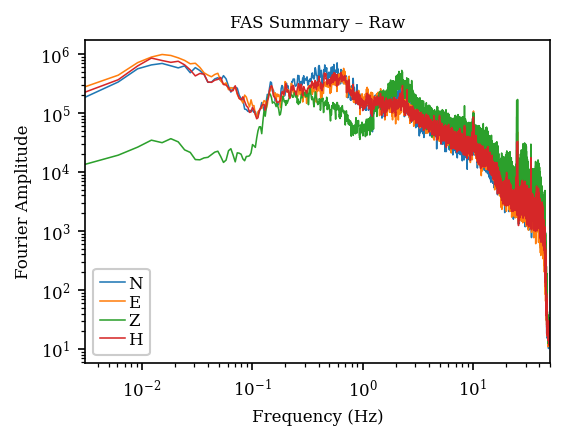

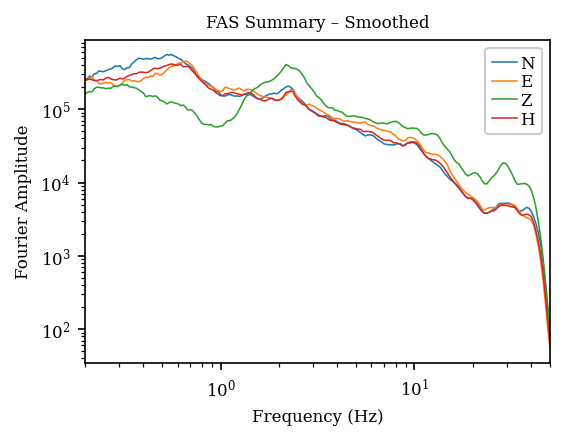

In [44]:

print("FAS raw frequencies:", fas_raw.frequency.shape)
print("FAS smooth frequencies:", fas_smooth.frequency.shape)
print("PSD raw frequencies:", psd_raw.frequency.shape)
print("PSD smooth frequencies:", psd_smooth.frequency.shape)

fig, ax = plot_spectrum_summary(fas_raw, include_horizontal=True, statistic="median")
ax.set_title("FAS Summary – Raw")
plt.show()

fig, ax = plot_spectrum_summary(fas_smooth, include_horizontal=True, statistic="median")
ax.set_title("FAS Summary – Smoothed")
plt.show()


## Compare Horizontal Methods: `geometric_mean` vs `single_azimuth`

This cell demonstrates the new single-azimuth integration in the spectral compute path.


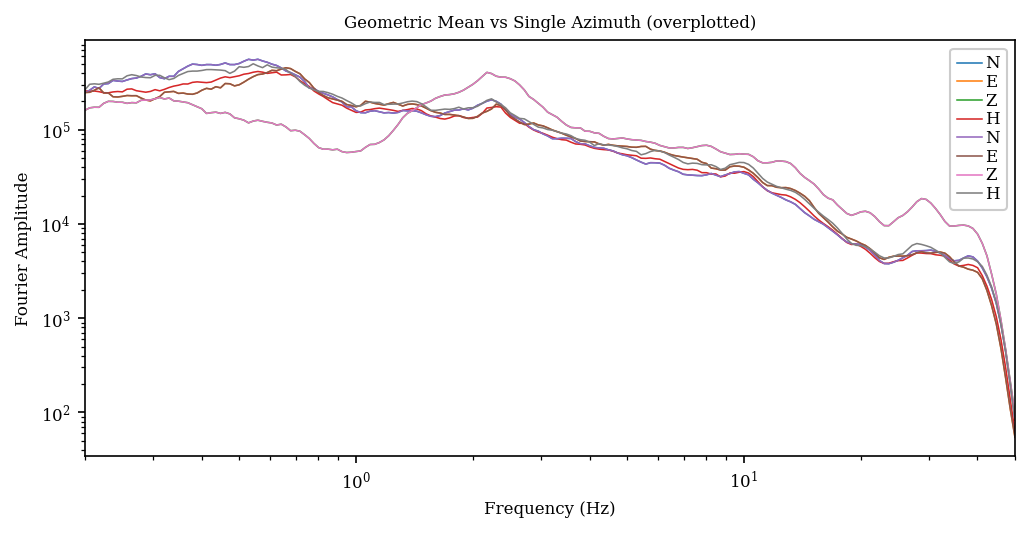

In [45]:

az_processing_settings = hvsrpy.settings.HvsrTraditionalProcessingSettings()
az_processing_settings.window_type_and_width = ("tukey", 0.2)
az_processing_settings.smoothing = dict(
    operator="konno_and_ohmachi",
    bandwidth=40,
    center_frequencies_in_hz=np.geomspace(0.2, 50, 200),
)
az_processing_settings.method_to_combine_horizontals = "single_azimuth"
az_processing_settings.azimuth_in_degrees = 30.0
az_processing_settings.handle_dissimilar_time_steps_by = "frequency_domain_resampling"

fas_single_az = compute_fourier_amplitude_spectra(
    srecords_accepted,
    az_processing_settings,
    include_horizontal=True,
    smooth=True,
)

fig, ax = plt.subplots(figsize=(8.0, 3.6), dpi=150)
plot_spectrum_summary(fas_smooth, include_horizontal=True, statistic="median", ax=ax)
plot_spectrum_summary(fas_single_az, include_horizontal=True, statistic="median", ax=ax)
ax.set_title("Geometric Mean vs Single Azimuth (overplotted)")
plt.show()


## Optional Save Block

Uncomment and adapt this block if you want to export the spectral figures.


In [ ]:

# save_figure = False
# fname_prefix = "example_spectral_extension"

# if save_figure:
#     fig_hvsr.savefig(f"{fname_prefix}_hvsr.png", dpi=300, bbox_inches="tight")
#     print("Saved HVSR figure.")


## Notes

- The spectral helpers are intended for **already preprocessed, already windowed, already accepted** HVSR records.
- The compute and plotting layers are now separated cleanly.
- `SpectralResult` is the preferred spectral result container.
- `plot_spectrum_component(...)` is the best primitive for notebook-specific layouts.
